# Embeddings Analysis
This notebook covers:
1. Training curves (loss + norm)
2. Genre family visualisation
3. All genres labelled
4. Intra-cluster vs global distance validation

## Setup

In [1]:
import os
os.chdir('..') 
print("Now working from:", os.getcwd())

Now working from: /Users/zofiabrodewicz/Documents/GitHub/Bachelor


In [14]:
import re
import itertools
import pickle

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
import tkinter as tk

import sys
sys.path.append('embeddings')
from lorentz import Lorentz

In [22]:
LOG_FILE = 'embeddings/training_log.txt'
CKPT = 'ckpt/final_enao_graph.ckpt'
VOCAB = 'enao_vocab.pkl'
MATRIX = 'enao_graph.npy'
DIM = 2
SEED = 42
N_SAMPLE = 5000000
FAMILIES = {
    'Pop': {
        'genres': ['pop', 'dance pop', 'canadian pop', 'uk pop', 'art pop',
                   'post-teen pop', 'bedroom pop', 'indie pop', 'viral pop',
                   'new wave pop', 'singer-songwriter pop', 'pov: indie'],
        'color': "stealblue"
    },
    'Rap': {
        'genres': ['rap', 'pop rap', 'melodic rap', 'cloud rap', 'gangster rap',
                   'east coast hip hop', 'southern hip hop', 'atl hip hop',
                   'french hip hop', 'west coast rap', 'conscious hip hop',
                   'chicago rap'],
        'color': "darkorange"
    },
    'Rock': {
        'genres': ['rock', 'modern rock', 'classic rock', 'alternative rock',
                   'hard rock', 'post-grunge', 'album rock', 'soft rock',
                   'indie rock', 'folk rock', 'pop rock', 'alternative metal'],
        'color': "mediumseagreen"
    },
    'Urbano Latino': {
        'genres': ['urbano latino', 'trap latino', 'reggaeton', 'musica mexicana',
                   'corrido', 'norteno', 'sierreno', 'banda', 'sad sierreno',
                   'reggaeton colombiano', 'latin pop', 'latin alternative'],
        'color': "mediumpurple"
    },
    'Hip Hop': {
        'genres': ['hip hop', 'trap', 'atl hip hop', 'southern hip hop',
                   'urban contemporary', 'east coast hip hop', 'conscious hip hop',
                   'french hip hop', 'german hip hop', 'canadian hip hop',
                   'latin hip hop', 'old school hip hop'],
        'color': "indianred"
    },
}


In [6]:
genres = pickle.load(open(VOCAB, 'rb'))
n_items = len(genres)
adj = np.load(MATRIX)
genre_to_idx = {g: i for i, g in enumerate(genres)}

net = Lorentz(n_items, DIM + 1)
net.load_state_dict(torch.load(CKPT, map_location='cpu'))
net.eval()

table = net.lorentz_to_poincare()
coords = table[1:]
x = coords[:, 0]
y = coords[:, 1]

lorentz_table = net.table.weight.data.cpu().numpy()

def lorentz_distance(u, v):
    inner = -u[0]*v[0] + np.dot(u[1:], v[1:])
    inner = np.clip(-inner, 1 + 1e-6, None)
    return float(np.arccosh(inner))

def get_embedding(genre_name):
    if genre_name not in genre_to_idx:
        return None
    idx = genre_to_idx[genre_name]
    return lorentz_table[idx + 1]


## 1. Training Curves

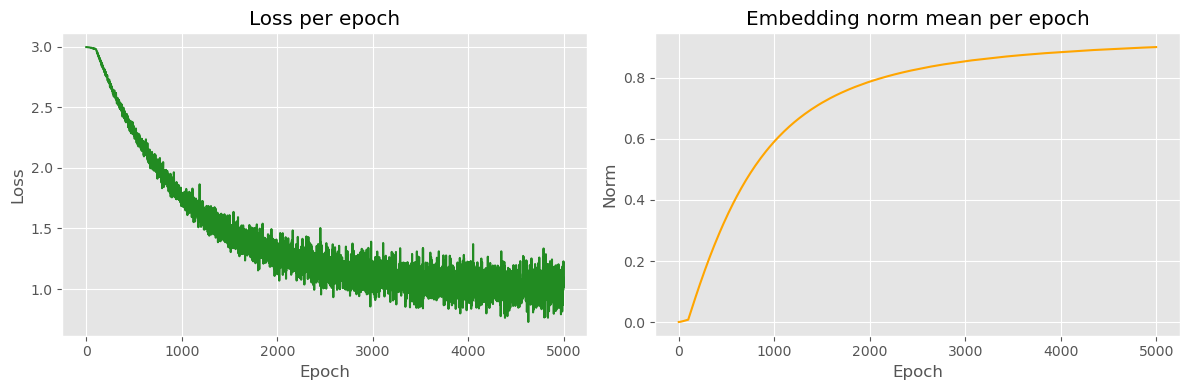

In [8]:
losses, norms = [], []
with open(LOG_FILE) as f:
    for line in f:
        m = re.search(r'Epoch \d+ \| loss: ([\d.]+) \| embedding norm mean: ([\d.]+)', line)
        if m:
            losses.append(float(m.group(1)))
            norms.append(float(m.group(2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses, color='forestgreen')
ax1.set_title('Loss per epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(norms, color='orange')
ax2.set_title('Embedding norm mean per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Norm')

plt.tight_layout()
# plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')  # uncomment to save
plt.show()

## 2. Genre Families Plot

In [23]:
NUDGE = {
    'trap':               ( 0.05,  0.06),
    'latin hip hop':      (-0.08,  0.08),
    'canadian hip hop':   ( 0.06, -0.07),
    'old school hip hop': (-0.10,  0.05),
    'southern hip hop':   ( 0.04,  0.09),
    'reggaeton':          (-0.09, -0.05),
}

fig, ax = plt.subplots(figsize=(22, 22))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.add_artist(plt.Circle((0, 0), 1, fill=False, edgecolor='#cccccc', linewidth=1.5))
ax.scatter(x, y, s=6, color='#d0d0d0', zorder=2, linewidths=0)

legend_patches = []

for family_name, info in FAMILIES.items():
    color = info['color']
    found_indices = [genre_to_idx[g] for g in info['genres'] if g in genre_to_idx]
    found_genres  = [g for g in info['genres'] if g in genre_to_idx]

    missing = [g for g in info['genres'] if g not in genre_to_idx]
    if missing:
        print(f'{family_name} — missing: {missing}')
    if not found_indices:
        continue

    ax.scatter(
        [x[i] for i in found_indices],
        [y[i] for i in found_indices],
        s=120, color=color, zorder=4, linewidths=0.5, edgecolors='white'
    )

    for i, genre in zip(found_indices, found_genres):
        dx, dy = NUDGE.get(genre, (0, 0.025))
        ax.annotate(
            genre,
            xy=(x[i], y[i]),
            xytext=(x[i] + dx, y[i] + dy),
            fontsize=20, ha='center', va='bottom',
            color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8),
            bbox= {'fc':'white', 'alpha': 0.95, 'edgecolor': color,
                  'linewidth': 0.6, 'pad': 2, 'boxstyle': 'round,pad=0.3'},
            zorder=5
        )

    legend_patches.append(mpatches.Patch(color=color, label=family_name))

legend = ax.legend(
    handles=legend_patches,
    loc='lower right',
    fontsize=14,
    framealpha=0.95,
    edgecolor='#cccccc',
    title='Genre Family',
    title_fontsize=15
)

ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Poincaré Disk — Genre Families', fontsize=20, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

## 3. All Genres Labelled

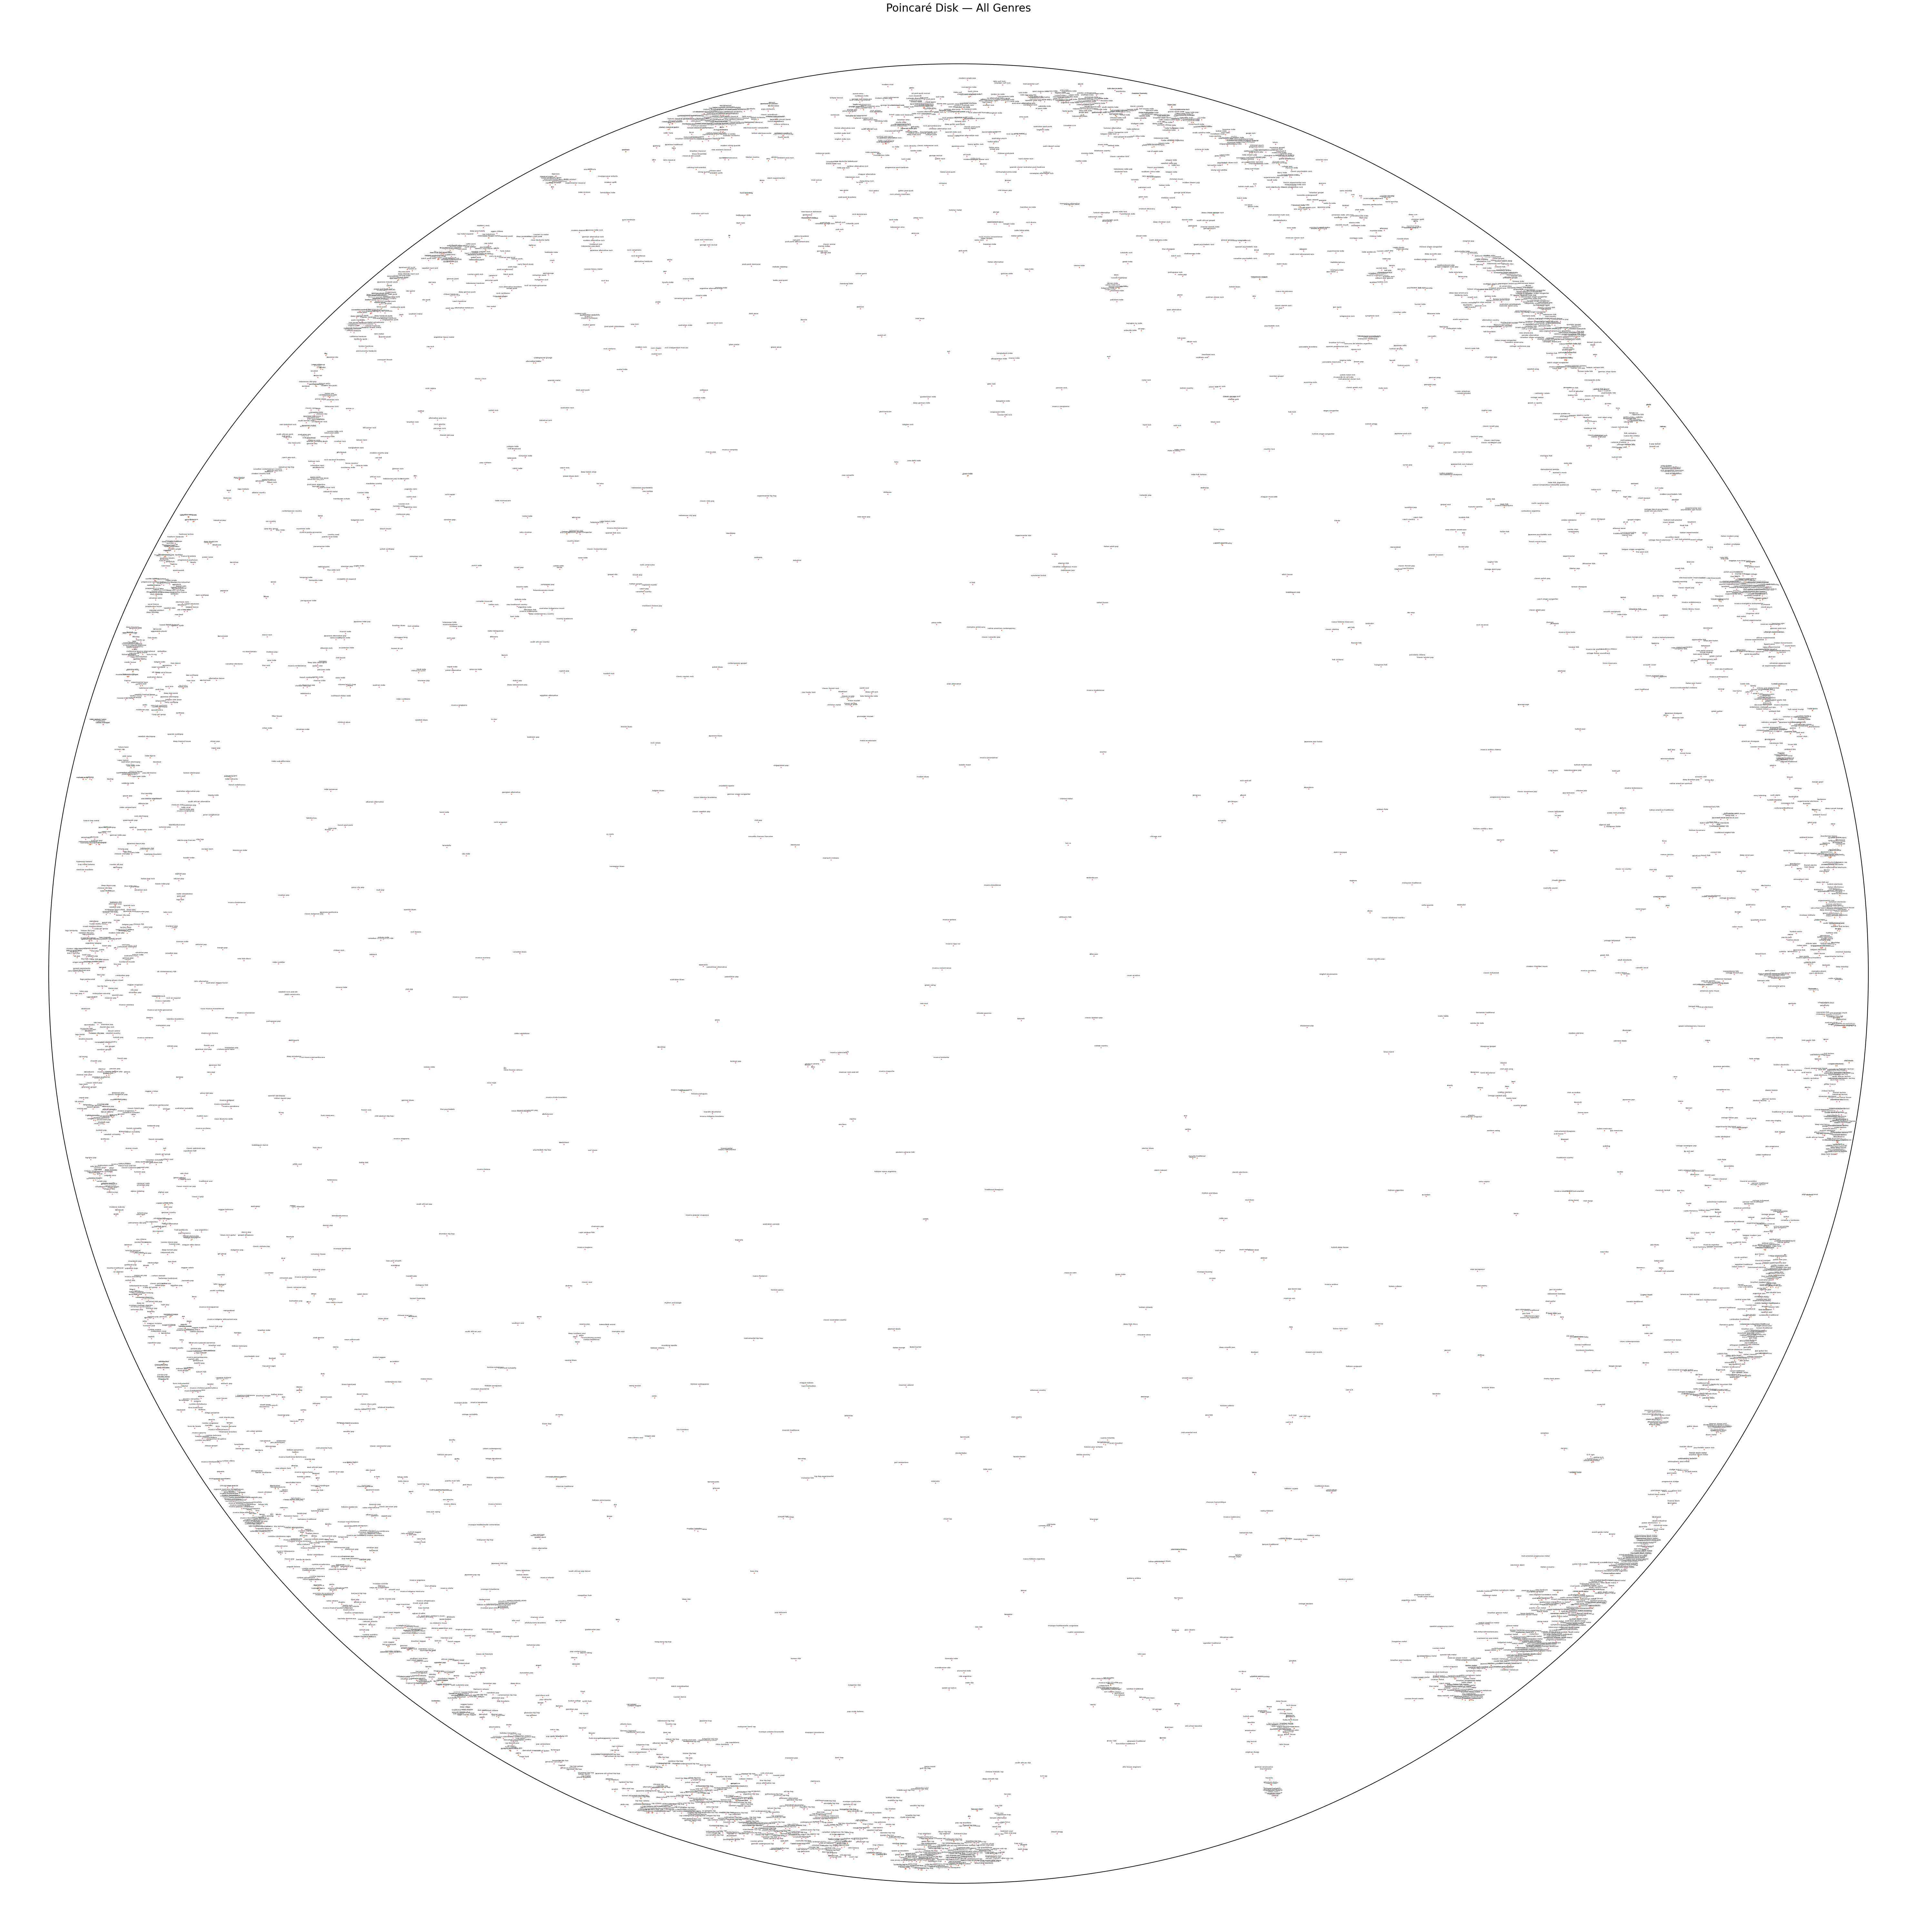

In [10]:
fig, ax = plt.subplots(figsize=(60, 60))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.add_artist(plt.Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5))
ax.scatter(x, y, s=5, color='tomato', zorder=2, linewidths=0)

for idx, genre in enumerate(genres):
    ax.annotate(genre, (x[idx], y[idx]), fontsize=4, ha='center', va='bottom',
                xytext=(0, 2), textcoords='offset points', zorder=3,
                bbox={'fc': 'white', 'alpha': 0.6, 'edgecolor': 'none', 'pad': 0.5})

ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Poincaré Disk — All Genres', fontsize=24, pad=15)
plt.tight_layout()
# plt.savefig('plot_all_genres.png', dpi=150, bbox_inches='tight')  # uncomment to save
plt.show()

## 4. Intra-cluster vs Global Distance Validation

Global average distance (random sample of 5000000 pairs): 5.7339

      Cluster  Genres found  Pairs  Intra-cluster mean  Intra-cluster std vs Global avg
          Pop            12     66              3.1090             1.7856      closer ✓
          Rap            12     66              2.0783             1.2631      closer ✓
         Rock            12     66              1.6848             1.0222      closer ✓
Urbano Latino            12     66              3.7900             2.5613      closer ✓
      Hip Hop            12     66              2.5321             1.2331      closer ✓

Global average distance: 5.7339


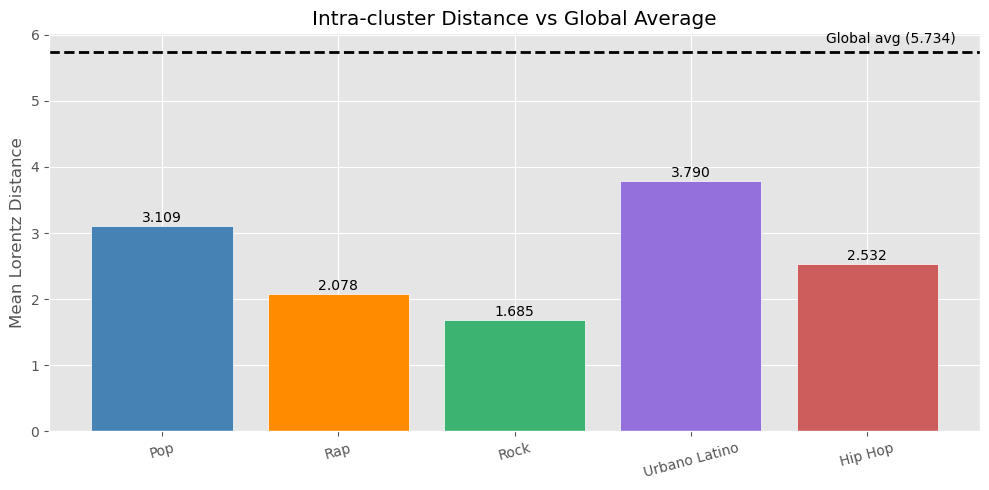

In [26]:
# global average distance (random sample of 5000 pairs) 
np.random.seed(SEED)
idx_a = np.random.randint(0, n_items, N_SAMPLE)
idx_b = np.random.randint(0, n_items, N_SAMPLE)
global_dists = [
    lorentz_distance(lorentz_table[i+1], lorentz_table[j+1])
    for i, j in zip(idx_a, idx_b) if i != j
]
global_avg = np.mean(global_dists)
print(f'Global average distance (random sample of {N_SAMPLE} pairs): {global_avg:.4f}')
print()

rows = []

# intra-cluster average distances 
for cluster_name, info in FAMILIES.items():
    genre_list = info['genres']
    found = [g for g in genre_list if g in genre_to_idx]
    missing = [g for g in genre_list if g not in genre_to_idx]
    if missing:
        print(f'  {cluster_name} — missing: {missing}')

    pairs = list(itertools.combinations(found, 2))
    if not pairs:
        continue

    dists = [
        lorentz_distance(get_embedding(g1), get_embedding(g2))
        for g1, g2 in pairs
        if get_embedding(g1) is not None and get_embedding(g2) is not None
    ]

    rows.append({
        'Cluster':            cluster_name,
        'Genres found':       len(found),
        'Pairs':              len(dists),
        'Intra-cluster mean': round(np.mean(dists), 4),
        'Intra-cluster std':  round(np.std(dists), 4),
        'vs Global avg':      'closer ✓' if np.mean(dists) < global_avg else 'further ✗'
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print(f'Global average distance: {global_avg:.4f}')

# bar chart 
fig, ax = plt.subplots(figsize=(10, 5))
cluster_names = df['Cluster'].tolist()
intra_means   = df['Intra-cluster mean'].tolist()
colors = ['#4682b4', '#ff8c00', '#3cb371', '#9370db', '#cd5c5c']

bars = ax.bar(cluster_names, intra_means, color=colors[:len(cluster_names)], edgecolor='white')
ax.axhline(global_avg, color='black', linewidth=2, linestyle='--')

# label directly on the line instead of legend
ax.text(len(cluster_names) - 0.5, global_avg + 0.1,
        f'Global avg ({global_avg:.3f})',
        ha='right', va='bottom', fontsize=10, color='black')

ax.set_ylabel('Mean Lorentz Distance')
ax.set_title('Intra-cluster Distance vs Global Average')
ax.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, intra_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
# plt.savefig('intra_cluster_distances.png', dpi=150, bbox_inches='tight')
plt.show()